Saving schematic as SVG (Vector)...
Saving schematic as PDF (High-Quality)...


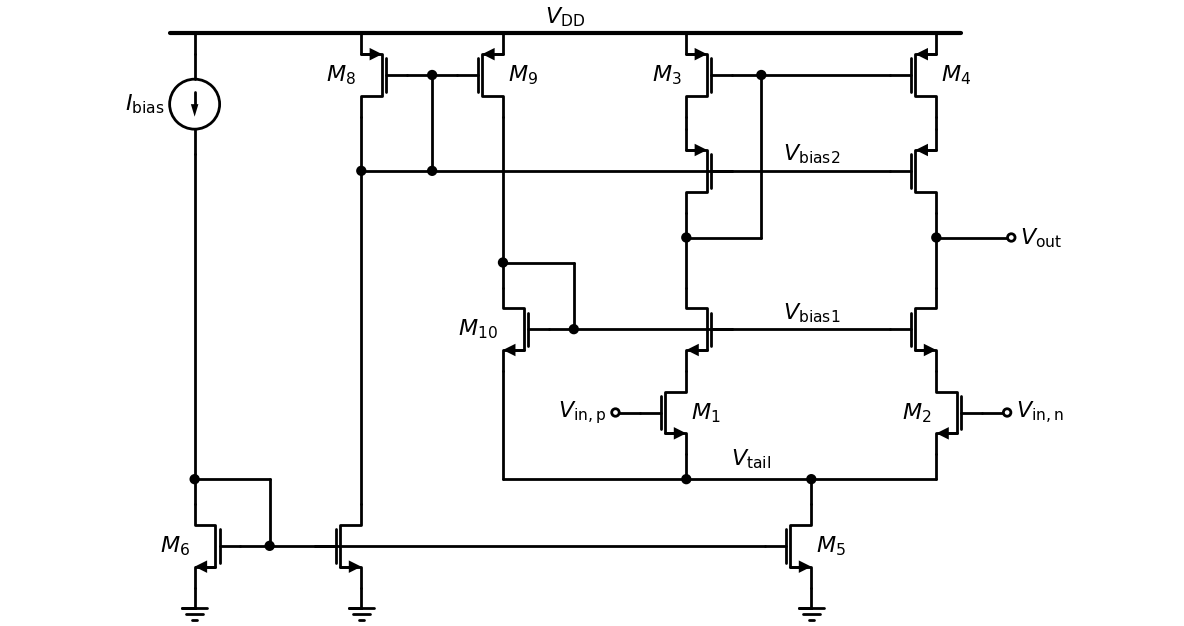

In [7]:
import schemdraw as sd
import schemdraw.elements as elm

# Configure schemdraw
# sd.svgconfig.svg2 = False

# Helper functions
def nfet(label=None, loc=None, reverse=False):
    fet = elm.AnalogNFet(offset_gate=False).theta(0)
    if reverse:
        fet = fet.reverse()
    if label:
        fet = fet.label(label, loc=loc) if loc else fet.label(label)
    return fet

def pfet(label=None, loc=None, reverse=False):
    fet = elm.AnalogPFet(offset_gate=False).theta(0)
    if reverse:
        fet = fet.reverse()
    if label:
        fet = fet.label(label, loc=loc) if loc else fet.label(label)
    return fet

# CHANGED: Removed canvas='svg' to use the default Matplotlib backend
with sd.Drawing() as d:
    d.config(unit=2, fontsize=16)

    # === Input differential pair (M1, M2) with cascode (M1C, M2C) ===
    M1C = nfet().drop('source')
    M1 = nfet('$M_1$', loc='right', reverse=True).drop('source')
    elm.Line().down(0.5)
    elm.Line().right(2.5).dot().label(r'$V_\mathrm{tail}$')
    d.push()

    # === Tail current source (M5) ===
    elm.Line().down(0.5)
    M5 = nfet('$M_5$', loc='right', reverse=True).anchor('drain')
    elm.Ground()

    # === Bias current mirror (M6, M7) ===
    elm.Line().left(9).at(M5.gate)
    d.push()
    M7 = nfet(reverse=True).anchor('gate').drop('source')
    elm.Ground()
    d.pop()
    elm.Line().left(1.5)
    M6 = nfet('$M_6$').anchor('gate')
    elm.Ground()

    # Bias current source connection
    elm.Line().up(0.5).dot().at(M6.drain)
    d.push()
    elm.Line().up().length(6.5)
    Ibias = elm.SourceI().up().label(r'$I_\mathrm{bias}$').reverse()
    d.pop()
    elm.Line().right().length(1.5)
    elm.Line().down().toy(M6.gate).dot()

    # === Continue with M2 side ===
    d.pop()
    elm.Line().right().length(2.5)
    elm.Line().up().length(0.5)
    M2 = nfet('$M_2$').anchor('source').drop('drain')
    M2C = nfet(reverse=True).anchor('source')

    # === Input terminals ===
    elm.Line().left().at(M1.gate).length(0.5).dot(open=True).label(r'$V_\mathrm{in,p}$', 'left')
    elm.Line().right().at(M2.gate).length(0.5).dot(open=True).label(r'$V_\mathrm{in,n}$', 'right')

    # === Load transistors (M3, M4) with cascode (M3C, M4C) ===
    # Left side (M3C, M3)
    elm.Line().up().at(M1C.drain).length(1).dot()
    d.push()
    elm.Line().up().length(0.5)
    M3C = pfet().anchor('drain').drop('source')
    elm.Line().up().length(0.25)
    M3 = pfet('$M_3$').anchor('drain')

    # Right side (M4C, M4) with output
    elm.Line().up().at(M2C.drain).length(1).dot()
    d.push()
    elm.Line().right().length(1.5).dot(open=True).label(r'$V_\mathrm{out}$', 'right')
    d.pop()
    elm.Line().up().length(0.5)
    M4C = pfet(reverse=True).anchor('drain').drop('source')
    elm.Line().up().length(0.25)
    M4 = pfet('$M_4$', loc='right', reverse=True).anchor('drain')

    # Connect M3-M4 gates and diode connection
    elm.Line().at(M4.gate).tox(M3.gate)
    d.pop()
    elm.Line().right().length(1.5)
    elm.Line().up().toy(M3.gate).dot()

    # === Bias voltage labels ===
    elm.Line().at(M1C.gate).to(M2C.gate).label(r'$V_\mathrm{bias1}$')
    elm.Line().at(M3C.gate).to(M4C.gate).label(r'$V_\mathrm{bias2}$')

    # === VDD rail ===
    line1 = elm.Line().at(Ibias.end).toy(M3.source)
    elm.Line().at((line1.end[0] - d.unit/4, line1.end[1])).to(
        (M4.source[0] + d.unit/4, M4.source[1])).label(r'$V_\mathrm{DD}$').linewidth(3)

    # === Bias generation circuitry (M8, M9, M10) ===
    # M8 - PMOS bias
    elm.Line().at(M7.drain).up().toy(M3.drain)
    M8 = pfet('$M_8$').anchor('drain')
    elm.Line().at(M8.gate).right(0.5).dot()
    d.push()
    elm.Line().right(0.5)
    M9 = pfet('$M_9$', loc='right', reverse=True).anchor('gate').drop('drain')
    d.pop()
    elm.Line().down().toy(M3C.gate).dot()
    elm.Line().right().to(M3C.gate).hold()
    elm.Line().left().tox(M8.drain).dot()

    # M10 - NMOS bias
    elm.Line().at(M9.drain).down().toy(M1C.drain)
    M10 = nfet('$M_{10}$').anchor('drain').drop('source')
    elm.Line().down().toy(M1.source - 0.5)
    elm.Line().right().tox(M1.source).dot()

    # M10 gate connection to cascode bias
    elm.Line().at(M10.gate).right(0.5).dot()
    elm.Line().right().to(M1C.gate).hold()
    elm.Line().up().toy(M10.drain + 0.5)
    elm.Line().left().tox(M10.drain).dot()

    # CHANGED: Save the file as PNG
    # Save as High-Resolution PNG (300 or 600 DPI is standard for print)
    print("Saving schematic as SVG (Vector)...")
    d.save('ota_improved_w_bias_vector.svg', dpi=600)
    
    print("Saving schematic as PDF (High-Quality)...")
    d.save('ota_improved_w_bias_vector.pdf')

Saving schematic as SVG (Vector)...
Saving schematic as PDF (High-Quality)...


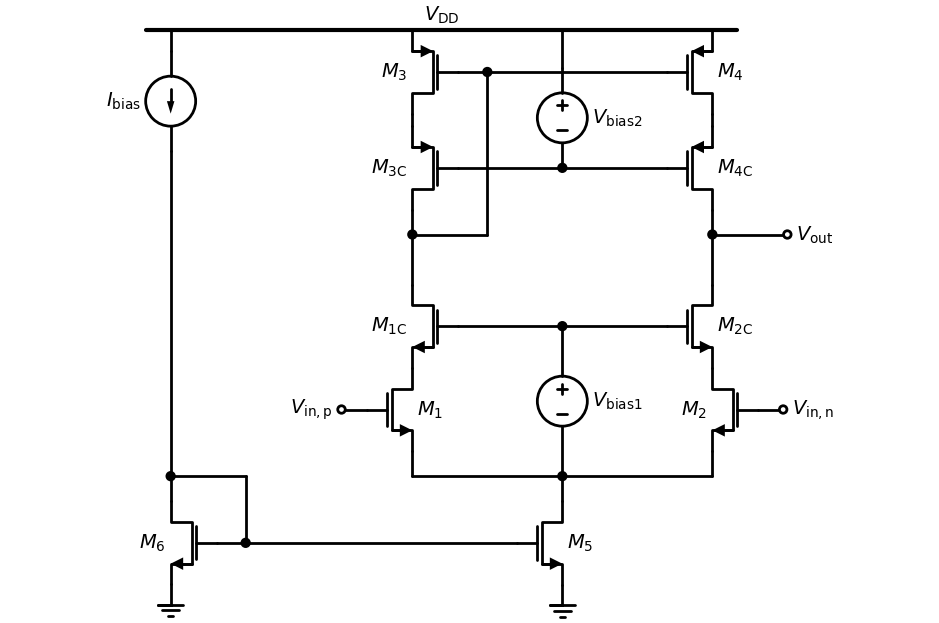

In [8]:
import schemdraw as sd
import schemdraw.elements as elm
import matplotlib.pyplot as plt

# 1. Force Matplotlib to use a non-interactive backend (prevents screen-resolution limits)
import matplotlib
matplotlib.use('Agg') 

# 2. Configure Schemdraw
# sd.svgconfig.svg2 = False

# Helper functions
def nfet(label=None, loc=None, reverse=False):
    fet = elm.AnalogNFet(offset_gate=False).theta(0)
    if reverse:
        fet = fet.reverse()
    if label:
        fet = fet.label(label, loc=loc) if loc else fet.label(label)
    return fet

def pfet(label=None, loc=None, reverse=False):
    fet = elm.AnalogPFet(offset_gate=False).theta(0)
    if reverse:
        fet = fet.reverse()
    if label:
        fet = fet.label(label, loc=loc) if loc else fet.label(label)
    return fet

# 3. Create the Drawing
with sd.Drawing() as d:
    d.config(unit=2, fontsize=14, font='serif') # Serif font looks more academic (like IEEE papers)

    # === Input differential pair (M1, M2) with cascode (M1C, M2C) ===
    M1C = nfet(r'$M_\mathrm{1C}$').drop('source')
    M1 = nfet('$M_1$', loc='right', reverse=True).drop('source')
    elm.Line().down().length(0.5)
    
    # Tail connection
    elm.Line().right().length(3).dot()
    tailpoint = d.here
    d.push()

    # === Tail current source (M5) ===
    elm.Line().down().length(0.5)
    M5 = nfet('$M_5$', loc='right', reverse=True).anchor('drain')
    elm.Ground()

    # === Bias Mirror for Tail (M6) ===
    elm.Line().left().length(6).at(M5.gate)
    M6 = nfet('$M_6$').anchor('gate')
    elm.Ground()

    # Bias I_source
    elm.Line().up().dot().at(M6.drain).length(0.5)
    d.push()
    elm.Line().up().length(6.5)
    Ibias = elm.SourceI().up().label(r'$I_\mathrm{bias}$').reverse()
    d.pop()
    elm.Line().right().length(1.5)
    elm.Line().down().toy(M6.gate).dot()

    # === Right Branch (M2 side) ===
    d.pop()
    elm.Line().right().length(3)
    elm.Line().up().length(0.5)
    M2 = nfet('$M_2$').anchor('source').drop('drain')
    M2C = nfet(r'$M_\mathrm{2C}$', loc='right', reverse=True).anchor('source')

    # === Inputs ===
    elm.Line().left().at(M1.gate).length(0.5).dot(open=True).label(r'$V_\mathrm{in,p}$', 'left')
    elm.Line().right().at(M2.gate).length(0.5).dot(open=True).label(r'$V_\mathrm{in,n}$', 'right')

    # === Load (M3, M4) with Cascodes ===
    # Left side (M3C, M3)
    elm.Line().up().at(M1C.drain).length(1).dot()
    d.push()
    elm.Line().up().length(0.5)
    M3C = pfet(r'$M_\mathrm{3C}$').anchor('drain').drop('source')
    elm.Line().up().length(0.25)
    M3 = pfet('$M_3$').anchor('drain')

    # Right side (M4C, M4) + Output
    elm.Line().up().at(M2C.drain).length(1).dot()
    d.push()
    elm.Line().right().length(1.5).dot(open=True).label(r'$V_\mathrm{out}$', 'right')
    d.pop()
    elm.Line().up().length(0.5)
    M4C = pfet(r'$M_\mathrm{4C}$', loc='right', reverse=True).anchor('drain').drop('source')
    elm.Line().up().length(0.25)
    M4 = pfet('$M_4$', loc='right', reverse=True).anchor('drain')

    # Connect Gates (M3/M4)
    elm.Line().at(M4.gate).tox(M3.gate)
    d.pop()
    elm.Line().right().length(1.5)
    elm.Line().up().toy(M3.gate).dot()

    # === Ideal Voltage Sources for Bias ===
    # Vbias1 (Tail referenced)
    elm.Line().at(M1C.gate).tox(M5.drain).dot()
    d.push()
    elm.Line().tox(M2C.gate)
    d.pop()
    Vbias1 = elm.SourceV().down().to(tailpoint).label(r'$V_\mathrm{bias1}$', loc='bottom').reverse()

    # Vbias2 (VDD referenced)
    elm.Line().at(M3C.gate).tox(M5.drain).dot()
    d.push()
    elm.Line().to(M4C.gate)
    d.pop()
    Vbias2 = elm.SourceV().up().label(r'$V_\mathrm{bias2}$', loc='bottom')
    elm.Line().toy(M3.source)

    # === VDD Rail ===
    line1 = elm.Line().at(Ibias.end).toy(M3.source)
    elm.Line().at((line1.end[0] - d.unit/4, line1.end[1])).to(
        (M4.source[0] + d.unit/4, M4.source[1])).label(r'$V_\mathrm{DD}$').linewidth(3)

    # 4. Save as SVG (True Vector) and PDF
    print("Saving schematic as SVG (Vector)...")
    d.save('ota_improved_vector.svg', dpi=600)
    
    print("Saving schematic as PDF (High-Quality)...")
    d.save('ota_improved_vector.pdf')